# 2.1 TX Repair

Explicit frame format:

`5s silence + Zadoff-Chu sync + pilot symbols + message symbols + 3s silence`

The pilot and message symbols are concatenated before sinc pulse shaping, so the payload is one continuous shaped waveform.

In [9]:
import sys
from pathlib import Path

import numpy as np
from scipy.io import wavfile

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT / 'src'))

from data_utils import load_bitstream
from modulator import (
    map_bits_to_symbols,
    normalize_audio,
    pulse_shape_symbols,
    to_int16_pcm,
    upconvert_to_passband,
)
from sync import generate_zadoff_chu_audio, make_silence

import config

## Fixed TX Parameters

In [10]:
START_SILENCE_SECONDS = 5.0
END_SILENCE_SECONDS = 3.0

MESSAGE_PATH = PROJECT_ROOT / 'data' / 'message.txt'
OUTPUT_PATH = PROJECT_ROOT / 'data' / 'tx_2_1_repair.wav'

FS = config.FS
F_CARRIER = config.F_CARRIER
SYMBOL_RATE = config.SYMBOL_RATE
SAMPLES_PER_SYMBOL = config.SAMPLES_PER_SYMBOL
M = config.M
MODULATION_METHOD = config.modulation_method
PULSE_METHOD = config.pulse_method
TOTAL_QAM_SYMBOLS = config.total_symbols
ZC_LENGTH = config.len_zadoff_chu
ZC_ROOT = config.u_zadoff_chu

print(f'FS: {FS} Hz')
print(f'Carrier: {F_CARRIER} Hz')
print(f'Symbol rate: {SYMBOL_RATE} baud')
print(f'Samples/symbol: {SAMPLES_PER_SYMBOL}')
print(f'Modulation: {M}-{MODULATION_METHOD}')
print(f'Pulse shape: {PULSE_METHOD}')
print(f'Zadoff-Chu: N={ZC_LENGTH}, root={ZC_ROOT}')
print(f'TOTAL_QAM_SYMBOLS: {TOTAL_QAM_SYMBOLS}')

FS: 44100 Hz
Carrier: 10000 Hz
Symbol rate: 6300 baud
Samples/symbol: 7
Modulation: 4-QAM
Pulse shape: SINC
Zadoff-Chu: N=353, root=7
TOTAL_QAM_SYMBOLS: 5000


## Load Message And Pilots

In [11]:
message_bits = load_bitstream(MESSAGE_PATH)
bits_per_symbol = int(np.log2(M))
expected_message_bits = TOTAL_QAM_SYMBOLS * bits_per_symbol

if len(message_bits) != expected_message_bits:
    raise ValueError(
        f'Expected {expected_message_bits} message bits for {TOTAL_QAM_SYMBOLS} QAM symbols, '
        f'but got {len(message_bits)} bits from {MESSAGE_PATH}.'
    )

pilot_bits = np.asarray(config.pilot_bits, dtype=int)

message_symbols = map_bits_to_symbols(message_bits, M=M, METHOD=MODULATION_METHOD)
pilot_symbols = map_bits_to_symbols(pilot_bits, M=M, METHOD=MODULATION_METHOD)
payload_symbols = np.concatenate([pilot_symbols, message_symbols])

print(f'Message bits: {len(message_bits)}')
print(f'Message symbols: {len(message_symbols)}')
print(f'Pilot bits: {len(pilot_bits)}')
print(f'Pilot symbols: {len(pilot_symbols)}')
print(f'Total payload symbols: {len(payload_symbols)}')

Message bits: 10000
Message symbols: 5000
Pilot bits: 32
Pilot symbols: 16
Total payload symbols: 5016


## Build Baseband Frame

In [12]:
sync_audio = generate_zadoff_chu_audio(ZC_LENGTH, ZC_ROOT)

# Pulse-shape pilots and message together so the payload has one timing origin.
payload_signal = pulse_shape_symbols(
    payload_symbols,
    SAMPLES_PER_SYMBOL,
    METHOD=PULSE_METHOD,
)

start_silence = make_silence(START_SILENCE_SECONDS, FS, dtype=complex)
end_silence = make_silence(END_SILENCE_SECONDS, FS, dtype=complex)

baseband_frame = np.concatenate([
    start_silence,
    sync_audio,
    payload_signal,
    end_silence,
])

sync_start_idx = len(start_silence)
payload_start_idx = sync_start_idx + len(sync_audio)
first_symbol_sample_idx = payload_start_idx + config.SPAN * SAMPLES_PER_SYMBOL
message_symbol_start_idx = first_symbol_sample_idx + len(pilot_symbols) * SAMPLES_PER_SYMBOL

print(f'Sync starts at sample: {sync_start_idx}')
print(f'Payload waveform starts at sample: {payload_start_idx}')
print(f'First pilot decision sample is near: {first_symbol_sample_idx}')
print(f'First message decision sample is near: {message_symbol_start_idx}')
print(f'Baseband frame samples: {len(baseband_frame)}')
print(f'Baseband duration: {len(baseband_frame) / FS:.6f} s')

Sync starts at sample: 220500
Payload waveform starts at sample: 220853
First pilot decision sample is near: 220881
First message decision sample is near: 220993
Baseband frame samples: 388321
Baseband duration: 8.805465 s


## Upconvert And Save WAV

In [13]:
passband_signal = upconvert_to_passband(baseband_frame, FS, F_CARRIER)

# No Tukey window. Normalize exactly once after upconversion to avoid clipping.
normalized_passband = normalize_audio(passband_signal)
pcm_signal = to_int16_pcm(normalized_passband)

wavfile.write(OUTPUT_PATH, FS, pcm_signal)

print(f'Peak before normalization: {np.max(np.abs(passband_signal)):.6f}')
print(f'Peak after normalization: {np.max(np.abs(normalized_passband)):.6f}')
print(f'PCM dtype: {pcm_signal.dtype}')
print(f'PCM peak: {np.max(np.abs(pcm_signal))}')
print(f'Saved: {OUTPUT_PATH}')

Peak before normalization: 1.962278
Peak after normalization: 1.000000
PCM dtype: int16
PCM peak: 32767
Saved: c:\Users\Ishaan\Ishaan\IITM\Sem6\CommSys\Project\transceiver-project\data\tx_2_1_repair.wav


## Frame Summary For RX

In [14]:
frame_summary = {
    'fs': FS,
    'carrier_hz': F_CARRIER,
    'symbol_rate': SYMBOL_RATE,
    'samples_per_symbol': SAMPLES_PER_SYMBOL,
    'modulation': f'{M}-{MODULATION_METHOD}',
    'pulse': PULSE_METHOD,
    'zc_length': ZC_LENGTH,
    'zc_root': ZC_ROOT,
    'start_silence_samples': len(start_silence),
    'sync_start_idx': sync_start_idx,
    'payload_waveform_start_idx': payload_start_idx,
    'first_pilot_decision_idx': first_symbol_sample_idx,
    'num_pilot_symbols': len(pilot_symbols),
    'num_message_symbols': len(message_symbols),
    'first_message_decision_idx': message_symbol_start_idx,
    'end_silence_samples': len(end_silence),
    'total_samples': len(baseband_frame),
}

frame_summary

{'fs': 44100,
 'carrier_hz': 10000,
 'symbol_rate': 6300,
 'samples_per_symbol': 7,
 'modulation': '4-QAM',
 'pulse': 'SINC',
 'zc_length': 353,
 'zc_root': 7,
 'start_silence_samples': 220500,
 'sync_start_idx': 220500,
 'payload_waveform_start_idx': 220853,
 'first_pilot_decision_idx': 220881,
 'num_pilot_symbols': 16,
 'num_message_symbols': 5000,
 'first_message_decision_idx': 220993,
 'end_silence_samples': 132300,
 'total_samples': 388321}

## Compare Repaired TX Against Old Single Carrier TX

This plots baseband windows for Zadoff-Chu, pilot region, and message region for both WAVs.

old_tx_single_carrier_test: zc_idx=220500, payload_idx=220853, first_symbol_idx=220881, message_idx=220993
new_tx_2_1_repair: zc_idx=220500, payload_idx=220853, first_symbol_idx=220881, message_idx=220993


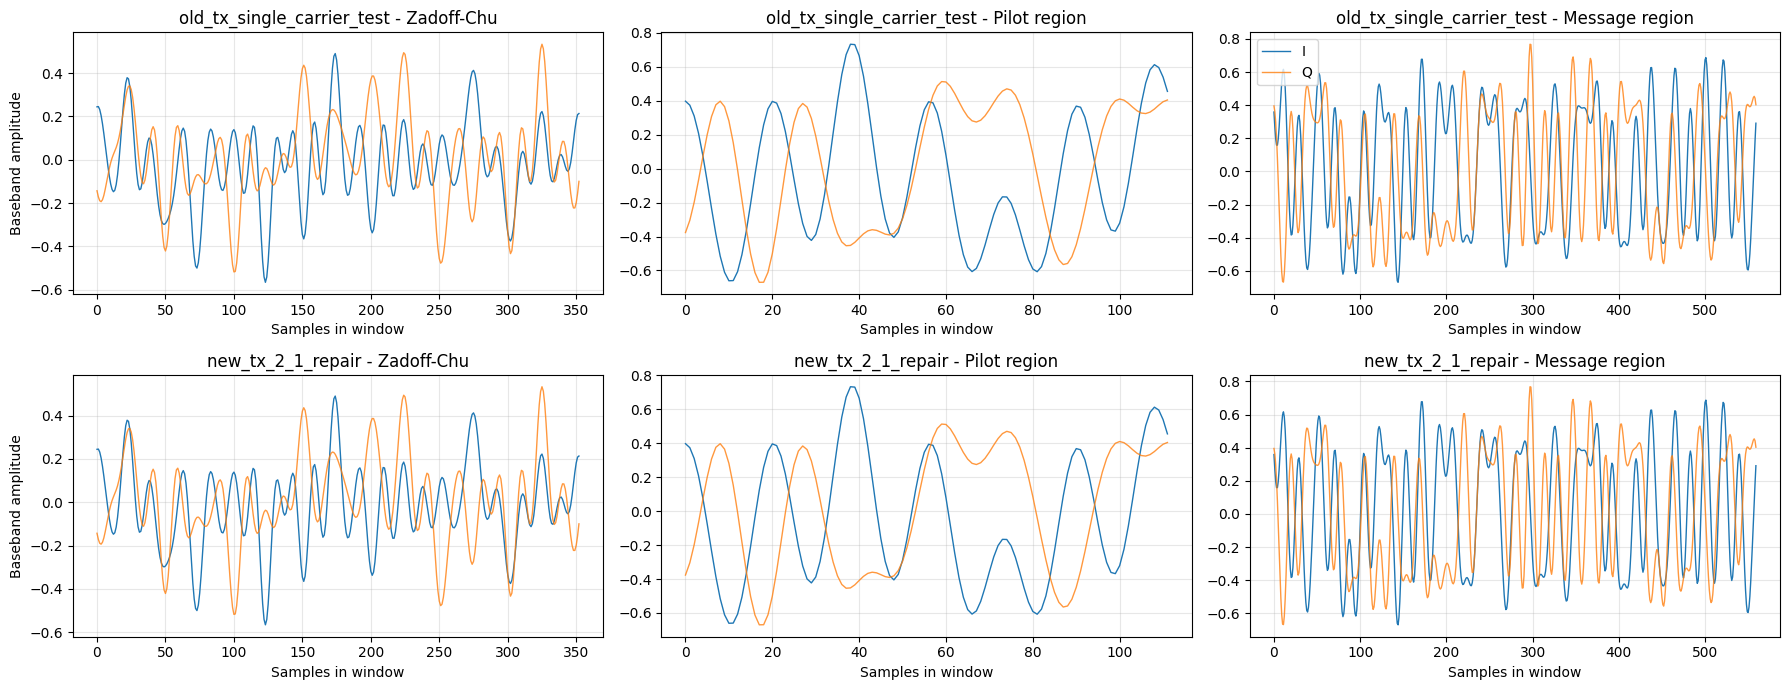

In [15]:
import matplotlib.pyplot as plt

from demodulator import downconvert_to_baseband, load_mono_normalized_audio, matched_filter_sync

compare_paths = {
    'old_tx_single_carrier_test': PROJECT_ROOT / 'data' / 'tx_single_carrier_test.wav',
    'new_tx_2_1_repair': PROJECT_ROOT / 'data' / 'tx_2_1_repair.wav',
}

reference_zc = generate_zadoff_chu_audio(ZC_LENGTH, ZC_ROOT)
payload_delay_samples = config.SPAN * SAMPLES_PER_SYMBOL
pilot_region_samples = len(pilot_symbols) * SAMPLES_PER_SYMBOL
message_region_samples = min(80 * SAMPLES_PER_SYMBOL, len(message_symbols) * SAMPLES_PER_SYMBOL)

fig, axes = plt.subplots(len(compare_paths), 3, figsize=(18, 7), sharex=False)

for row, (label, wav_path) in enumerate(compare_paths.items()):
    fs_cmp, audio_cmp = load_mono_normalized_audio(wav_path)
    if fs_cmp != FS:
        raise ValueError(f'{label}: expected {FS} Hz, got {fs_cmp} Hz')

    bb_cmp = downconvert_to_baseband(
        audio_cmp,
        fs_cmp,
        F_CARRIER,
        cutoff_hz=3500,
        filter_order=5,
    )
    zc_idx, corr = matched_filter_sync(bb_cmp, reference_zc)
    payload_idx = zc_idx + ZC_LENGTH
    first_symbol_idx = payload_idx + payload_delay_samples
    message_idx = first_symbol_idx + pilot_region_samples

    windows = [
        ('Zadoff-Chu', zc_idx, ZC_LENGTH),
        ('Pilot region', first_symbol_idx, pilot_region_samples),
        ('Message region', message_idx, message_region_samples),
    ]

    print(f"{label}: zc_idx={zc_idx}, payload_idx={payload_idx}, first_symbol_idx={first_symbol_idx}, message_idx={message_idx}")

    for col, (title, start, n_samples) in enumerate(windows):
        segment = bb_cmp[start:start + n_samples]
        x = np.arange(len(segment))
        ax = axes[row, col] if len(compare_paths) > 1 else axes[col]
        ax.plot(x, np.real(segment), label="I", linewidth=1)
        ax.plot(x, np.imag(segment), label="Q", linewidth=1, alpha=0.8)
        ax.set_title(f"{label} - {title}")
        ax.set_xlabel("Samples in window")
        ax.grid(True, alpha=0.3)
        if col == 0:
            ax.set_ylabel("Baseband amplitude")
        if row == 0 and col == 2:
            ax.legend()

plt.tight_layout()
plt.show()


## Fair Message Comparison

The old file starts message symbols immediately after ZC. The repaired file starts message symbols after the pilot symbols. This cell aligns those two message starts.

old_tx_single_carrier_test: aligned message_start_idx=220500, samples_plotted=840
new_tx_2_1_repair: aligned message_start_idx=220500, samples_plotted=840


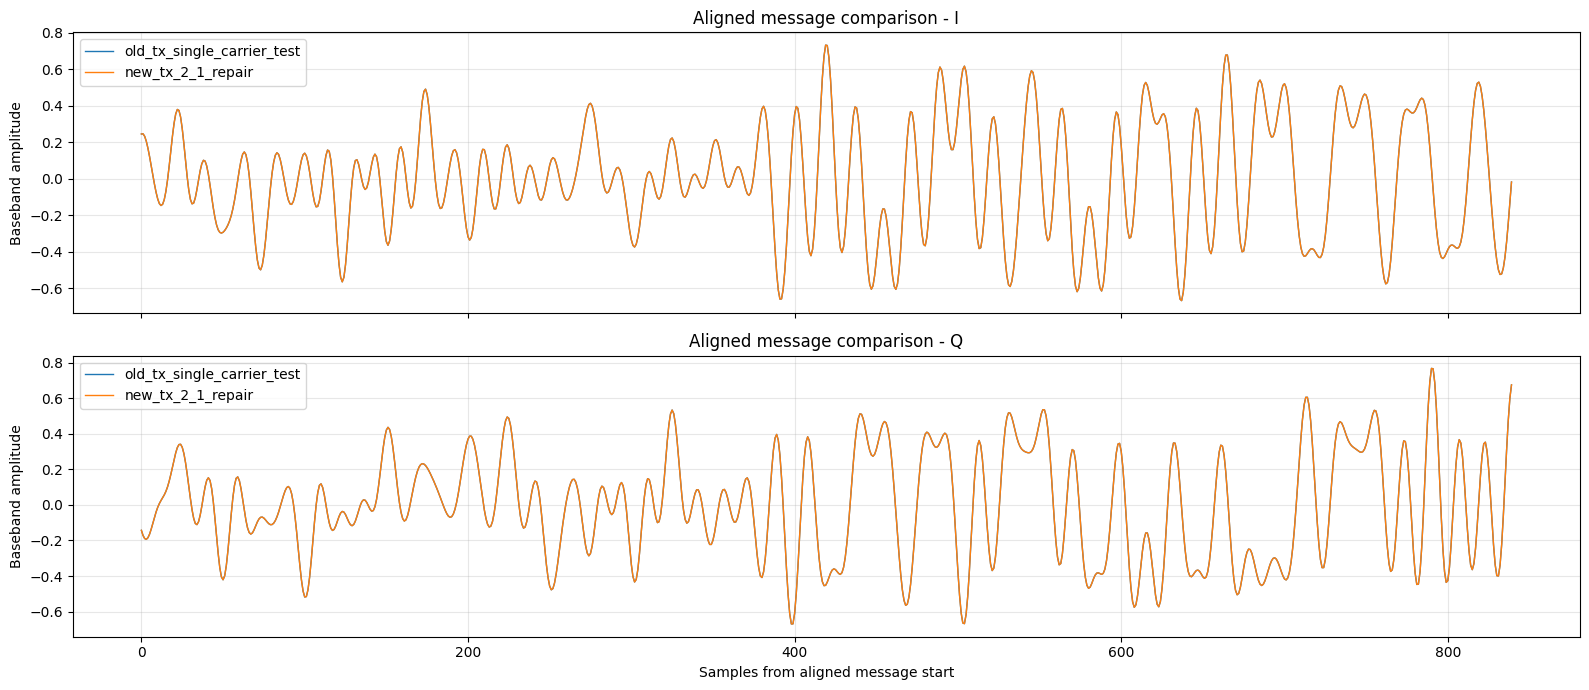

In [16]:
message_compare_symbols = 120
message_compare_samples = message_compare_symbols * SAMPLES_PER_SYMBOL

aligned_segments = {}

for label, wav_path in compare_paths.items():
    fs_cmp, audio_cmp = load_mono_normalized_audio(wav_path)
    bb_cmp = downconvert_to_baseband(
        audio_cmp,
        fs_cmp,
        F_CARRIER,
        cutoff_hz=3500,
        filter_order=5,
    )
    zc_idx, _ = matched_filter_sync(bb_cmp, reference_zc)
    first_symbol_idx = zc_idx + ZC_LENGTH - 353
    message_start_idx = first_symbol_idx

    segment = bb_cmp[message_start_idx:message_start_idx + message_compare_samples]
    aligned_segments[label] = segment
    print(f"{label}: aligned message_start_idx={message_start_idx}, samples_plotted={len(segment)}")

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

for label, segment in aligned_segments.items():
    x = np.arange(len(segment))
    axes[0].plot(x, np.real(segment), label=label, linewidth=1)
    axes[1].plot(x, np.imag(segment), label=label, linewidth=1)

axes[0].set_title('Aligned message comparison - I')
axes[1].set_title('Aligned message comparison - Q')
axes[1].set_xlabel('Samples from aligned message start')

for ax in axes:
    ax.set_ylabel("Baseband amplitude")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()
